In [1]:
from pathlib import Path

nnunet_dir = Path("/nfs/data/nii/data1/Analysis/zanderch___HU_Messung/ANALYSIS_seg/nnunet")


## Method 2 : 
a) generate bboxs around L1 using totalsegmentator 
python experiments/vertebrae/segment_l1_totalseg.py
b) generate nnunet dataset with the cropped versions
python experiments/vertebrae/make_dataset002.py
c) train nnunet
nnUNetv2_plan_and_preprocess -np 16 -d 2 --verify_dataset_integrity -c 3d_fullres -pl nnUNetPlannerResEncM 
nnUNetv2_train 2 3d_fullres -p nnUNetResEncMUNetPlans 1


In [2]:
# eval nnunet on validation set
import json

dataset_name = "Dataset002_cropped"
imgs_dir     = nnunet_dir / "nnUNet_raw" / dataset_name / "imagesTr"
roi_dir      = nnunet_dir / "nnUNet_raw" / dataset_name / "labelsTr"
fold_id = 1
split_file_path = nnunet_dir / "nnUNet_preprocessed" / dataset_name / "splits_final.json"
splits = json.load(open(split_file_path))
val_cases = splits[fold_id]["val"]

# copy images and rois to new folder for evaluation
eval_imgs_dir = nnunet_dir / "nnUNet_raw" / dataset_name / "imagesTs"
eval_rois_dir = nnunet_dir / "nnUNet_raw" / dataset_name / "labelsTs"
eval_imgs_dir.mkdir(exist_ok=True)
eval_rois_dir.mkdir(exist_ok=True)
for case in val_cases:
    img_path = imgs_dir / f"{case}_0000.nii.gz"
    roi_path = roi_dir / f"{case}.nii.gz"
    img_eval_path = eval_imgs_dir / f"{case}_0000.nii.gz"
    roi_eval_path = eval_rois_dir / f"{case}.nii.gz"
    img_eval_path.symlink_to(img_path)
    roi_eval_path.symlink_to(roi_path)

FileExistsError: [Errno 17] File exists: '/nfs/data/nii/data1/Analysis/zanderch___HU_Messung/ANALYSIS_seg/nnunet/nnUNet_raw/Dataset002_cropped/imagesTr/24168972_20220508154531_0000.nii.gz' -> '/nfs/data/nii/data1/Analysis/zanderch___HU_Messung/ANALYSIS_seg/nnunet/nnUNet_raw/Dataset002_cropped/imagesTs/24168972_20220508154531_0000.nii.gz'

nnUNetv2_predict -i /nfs/data/nii/data1/Analysis/zanderch___HU_Messung/ANALYSIS_seg/nnunet/nnUNet_raw/Dataset002_cropped/imagesTs \
    -o /nfs/data/nii/data1/Analysis/zanderch___HU_Messung/ANALYSIS_seg/nnunet/nnUNet_raw/Dataset002_cropped/predsTs \
    -d 1 \
    -c 3d_fullres \
    -f 1 \
    -tr nnUNetTrainer \
    -p nnUNetResEncUNetMPlans \
    -chk checkpoint_best.pth

Dice:              0.7691
Dice (largest CC): 0.7691
Center distance:   2.27 mm


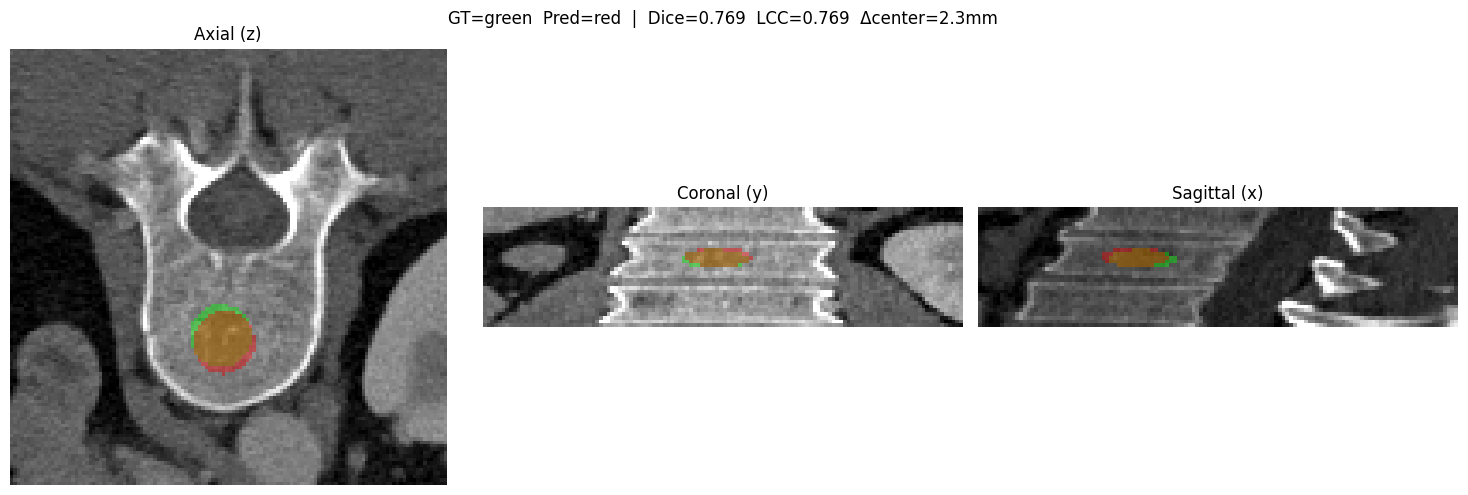

Dice:              0.5783
Dice (largest CC): 0.5783
Center distance:   3.99 mm


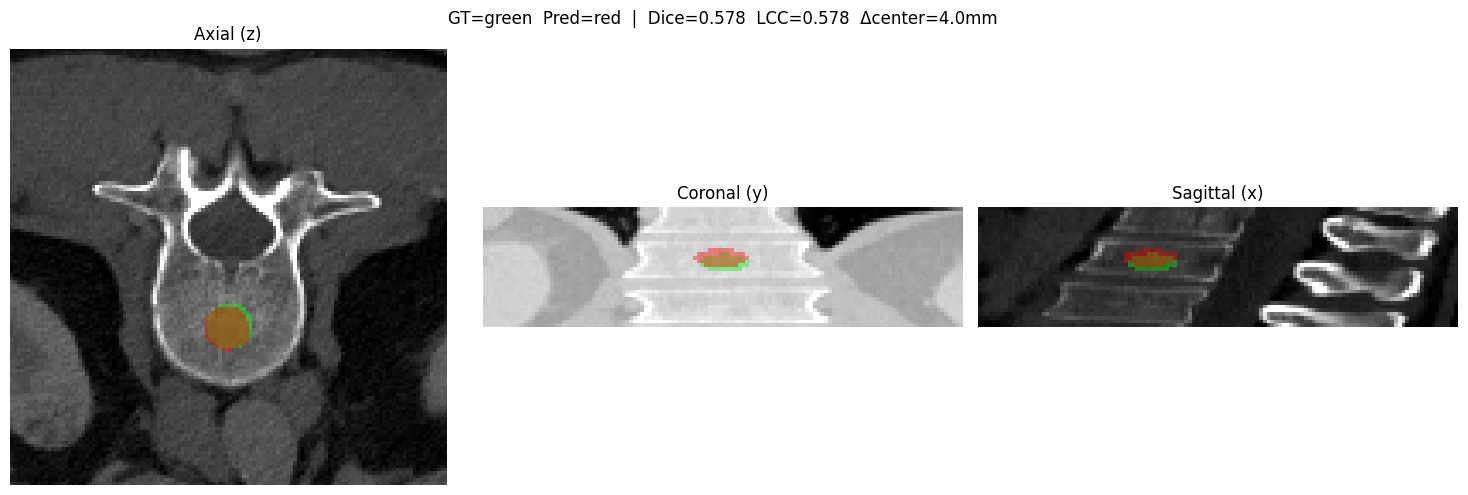

Dice:              0.7495
Dice (largest CC): 0.7495
Center distance:   1.88 mm


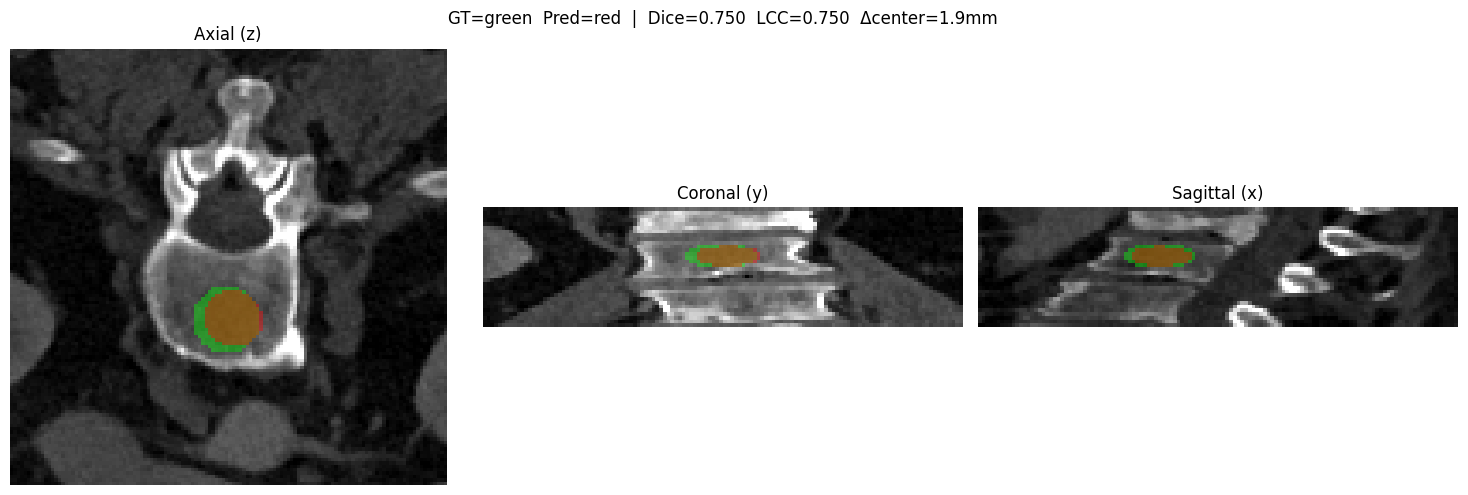

Dice:              0.5894
Dice (largest CC): 0.5894
Center distance:   2.40 mm


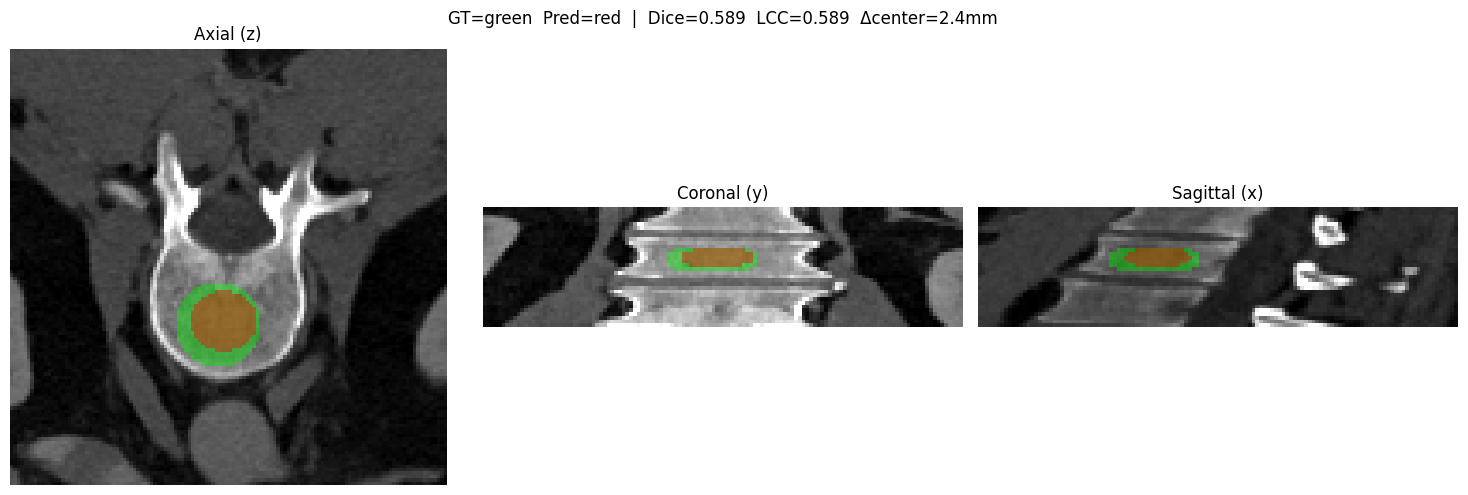

Dice:              0.7782
Dice (largest CC): 0.7782
Center distance:   2.13 mm


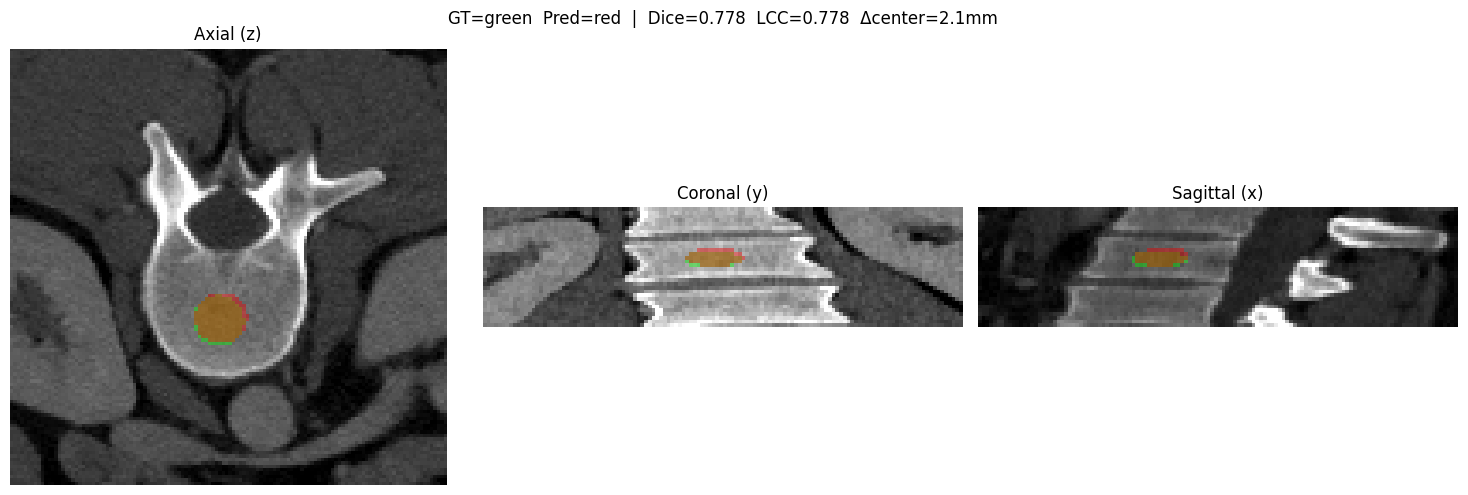

Dice:              0.5698
Dice (largest CC): 0.5698
Center distance:   3.80 mm


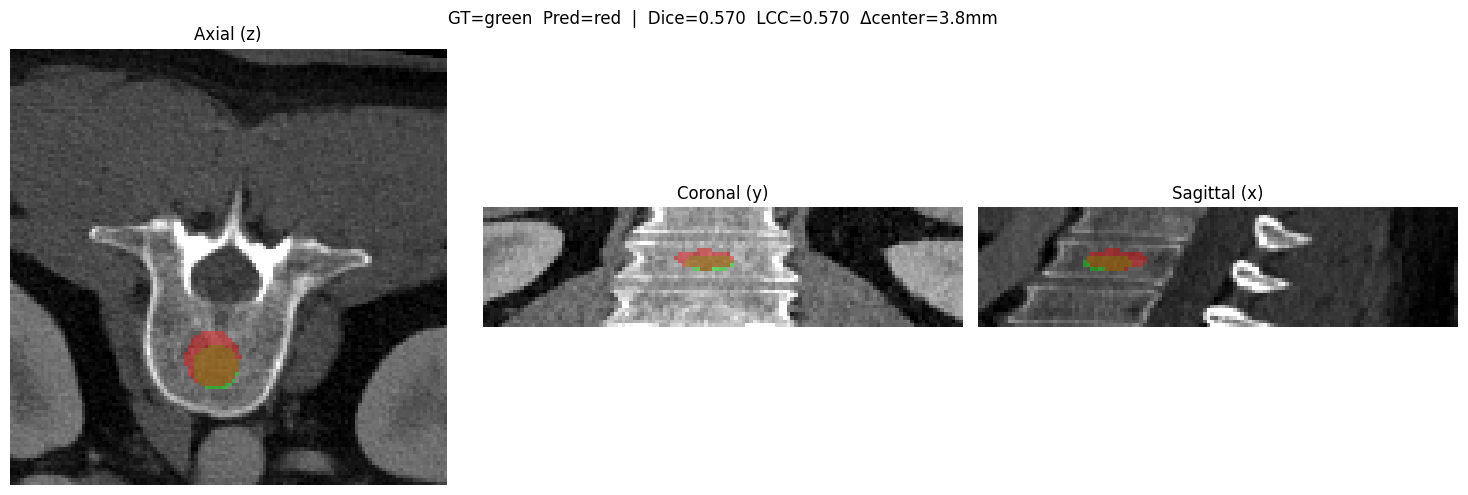

Dice:              0.8924
Dice (largest CC): 0.8924
Center distance:   0.93 mm


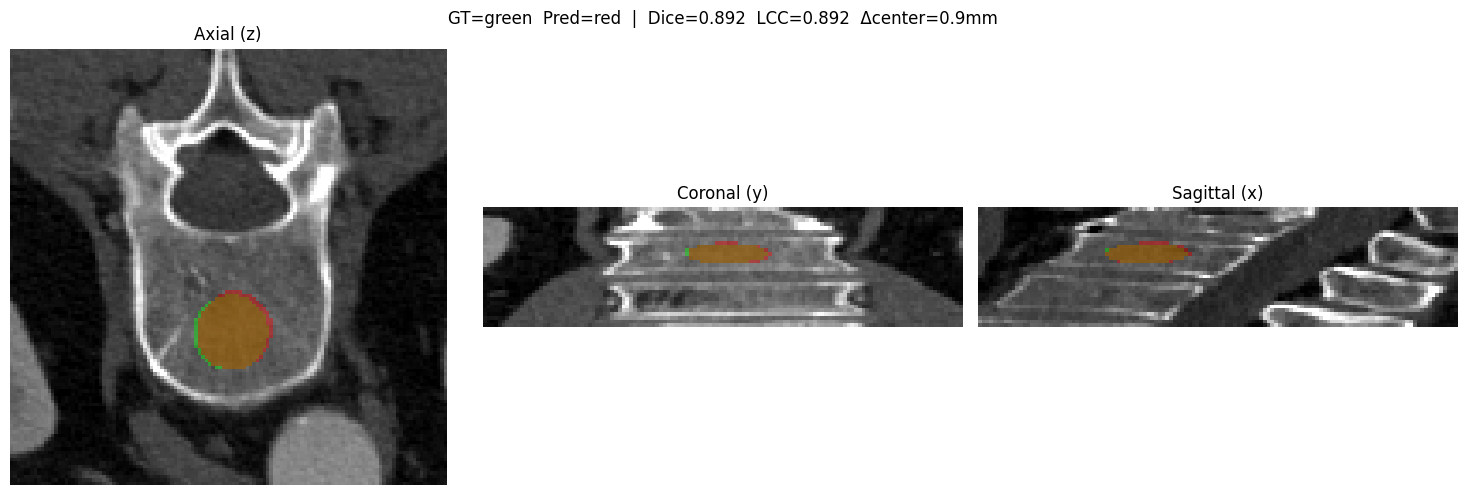

In [5]:
import sys
sys.path.insert(0, "/home/dpxuser/dev/whole_body_benchmark")
from src.utils.eval import eval_case
preds_dir = nnunet_dir / "nnUNet_raw" / dataset_name / "predsTs"

for case in val_cases:
    img_path = imgs_dir / f"{case}_0000.nii.gz"
    pred_path = preds_dir / f"{case}.nii.gz"
    gt_path = roi_dir / f"{case}.nii.gz"
    eval_case(img_path, pred_path, gt_path, label=1)


In [7]:
# export to nora 
import os

project_name = "zanderch___HU_Messung"
preds_dir = nnunet_dir / "nnUNet_raw" / dataset_name / "predsTs"
preds_regex = r"(?<patients_id>\d+)_(?<studies_id>\d+)\.nii\.gz"

print("Importing preds...")
print(f"nora -p {project_name} --importfiles {preds_dir} '{preds_regex}' 'preds/'")


Importing preds...
nora -p zanderch___HU_Messung --importfiles /nfs/data/nii/data1/Analysis/zanderch___HU_Messung/ANALYSIS_seg/nnunet/nnUNet_raw/Dataset002_cropped/predsTs '(?<patients_id>\d+)_(?<studies_id>\d+)\.nii\.gz' 'preds/'


source /software/anaconda3/etc/profile.d/conda.sh
conda activate segfm3d_2
export MPLCONFIGDIR=/software/matplotlib.conf

echo "image: $f1"
echo "gt: $f2"
echo "output pred l1: $o1"
echo "output crop: $o2"
echo "output pred: $o3"

# a) generate bboxs around L1 using totalsegmentator 
TotalSegmentator -i $f1 -o $o1 --task total --roi_subset vertebrae_L1 --device gpu --ml

# b) generate cropped image around predicted L1
python /nfs/data/nii/data1/Analysis/zanderch___HU_Messung/ANALYSIS_seg/crop_to_l1.py $f1 $o1 $o2

# c) generate roi prediction using the custom nnunet model 
export nnUNet_raw="/nfs/data/nii/data1/Analysis/zanderch___HU_Messung/ANALYSIS_seg/nnunet/nnUNet_raw"
export nnUNet_preprocessed="/nfs/data/nii/data1/Analysis/zanderch___HU_Messung/ANALYSIS_seg/nnunet/nnUNet_preprocessed"
export nnUNet_results="/nfs/data/nii/data1/Analysis/zanderch___HU_Messung/ANALYSIS_seg/nnunet/nnUNet_results"

nnUNetv2_predict -i $(dirname "$o2") -o $o3 -d 2 -c 3d_fullres -f 1 -p nnUNetResEncUNetMPlans -chk checkpoint_best.pth 

rm -f "$o3"/{dataset,plans,predict_from_raw_data_args}.json
